# Plot H and H Growth Curves
March 6, 2024

Check the matrix H and the locations of DG1 with different alpha values

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.model import Model

def plot_H(alpha, replicate):
    gene_name = 'CLB2'
    posteriors_path = f'data/2019_cloccs_fits/yl_2019_replicate{replicate}/posteriors.txt'

    config = create_dynamic_alpha_config(alpha, replicate)
    model = Model(config, gene_name)
    #chromatin_model = ChromatinModel(config)
    #chromatin_model.load_mnase_gene(gene_name)
    #chromatin_model.create_deconvolution_bins()
    #chromatin_model.setup_deconv_model()

    model.plot_H()

    return model

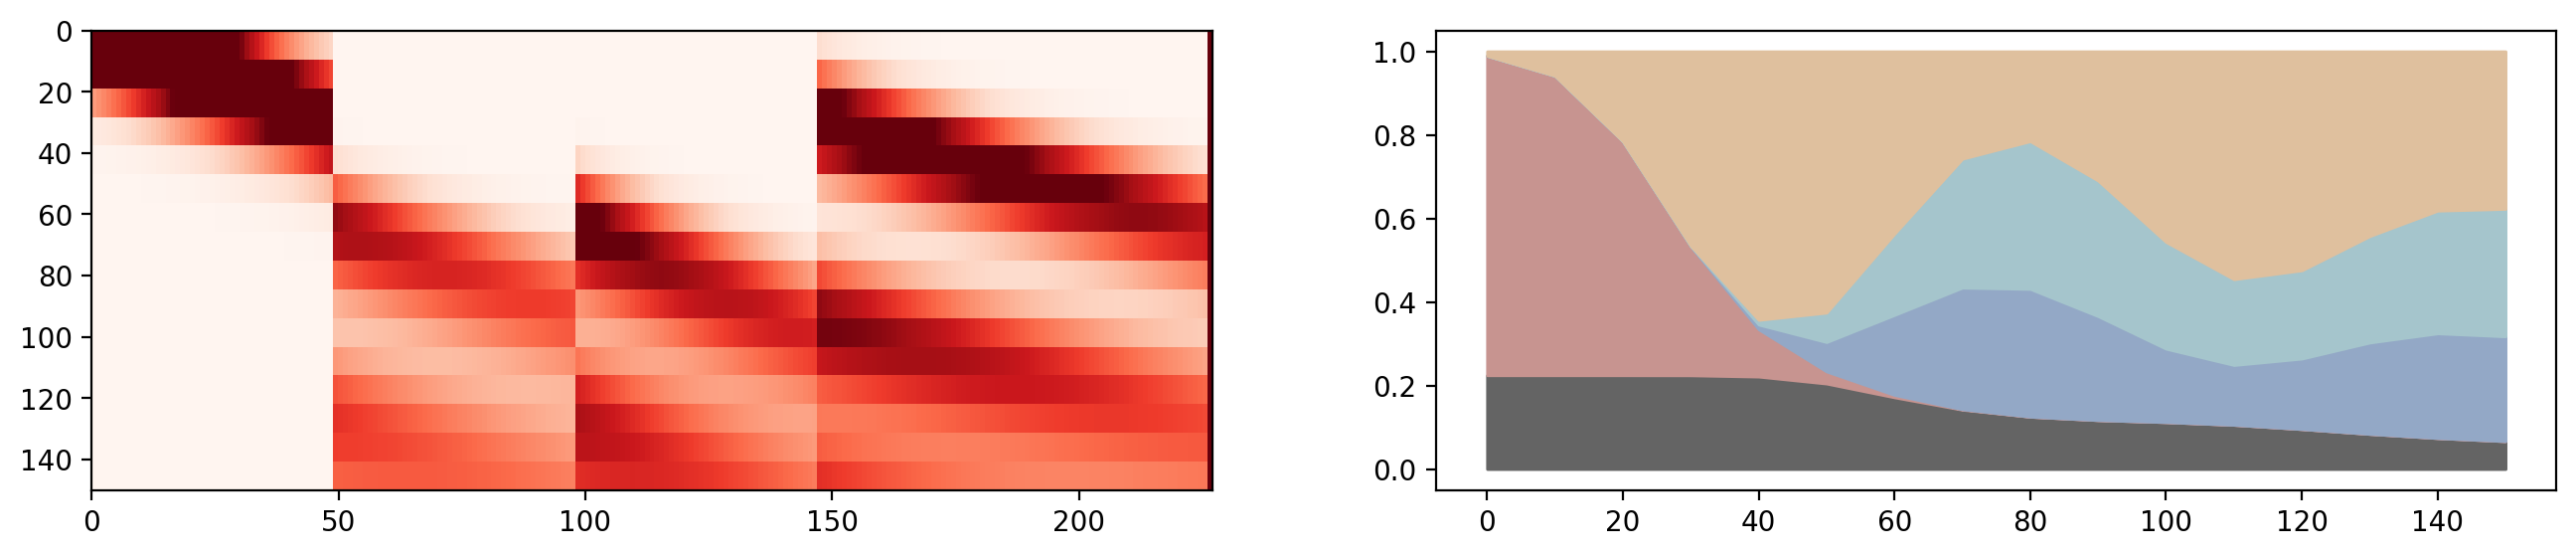

In [22]:
# This includes the expected daughter-specific delay
plot_H(alpha=28, replicate=1)

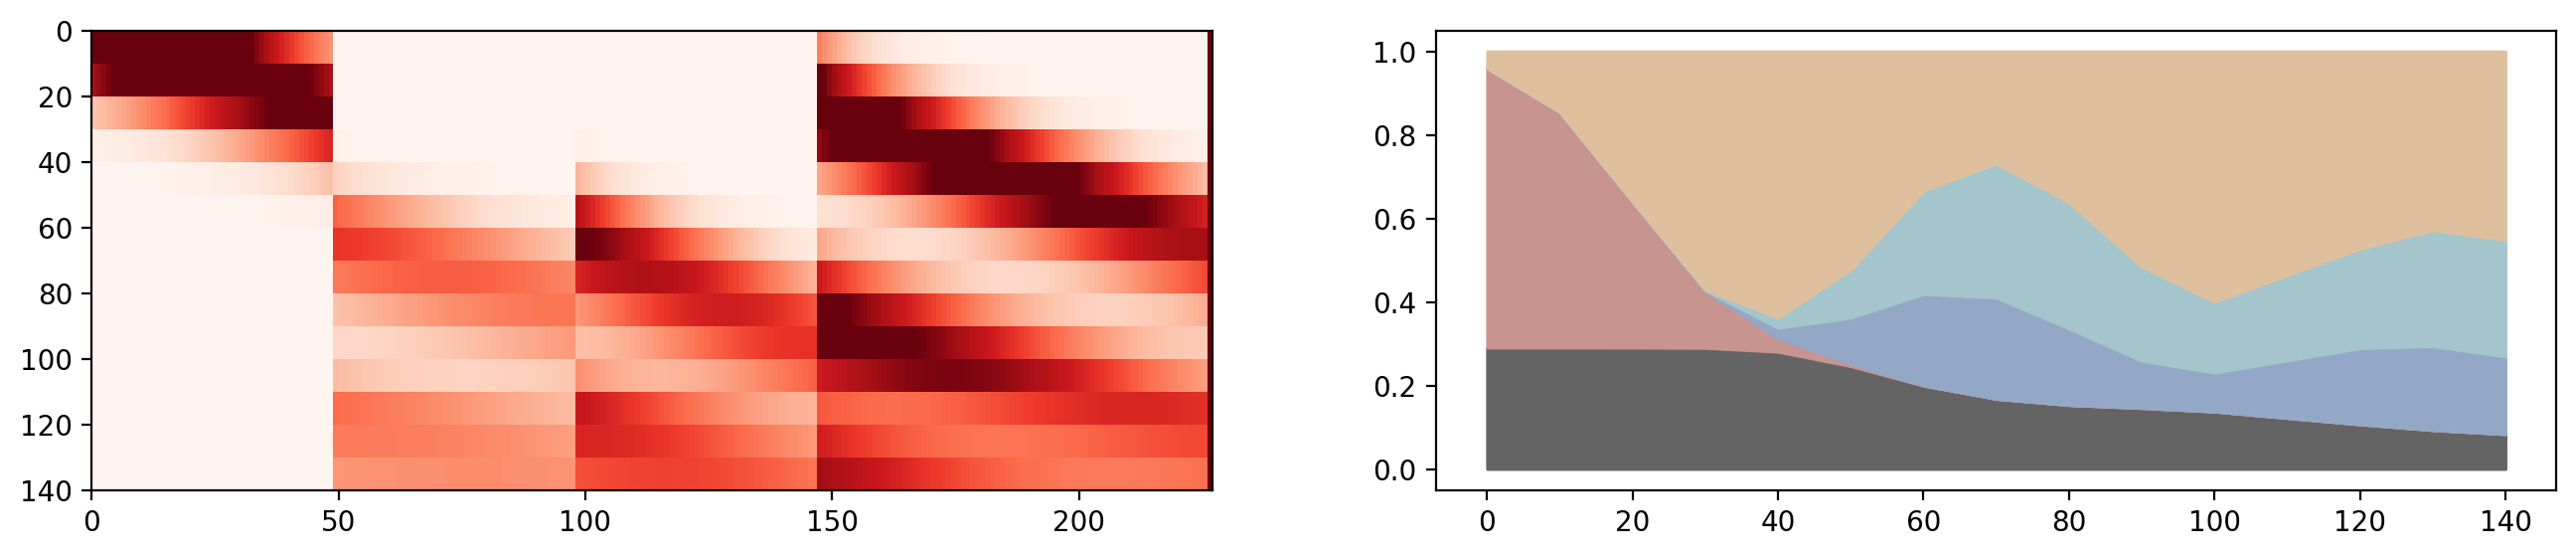

In [23]:
plot_H(alpha=19, replicate=2)

In [44]:
from src.create_models_S import ModelCreation as ModelCreationS
from src.config import Config, read_yl_vst_data_rep

# We can create a model that includes S

replicate = 1

alpha = 28

posteriors_path = f'data/2019_cloccs_fits/yl_2019_replicate{replicate}/posteriors.txt'
output_path = 'models/yl_cell_cycle/wt1_s_rg1.28.label'

model_creator = ModelCreationS(posteriors_path, output_path)
model_creator.alpha = alpha
model_creator.create_model()

config = Config(wt1=read_yl_vst_data_rep(replicate), model_wt1_file=output_path, 
                name=f'Replicate 1 S, $\\alpha$={alpha}', 
                replicate=1, alpha=alpha)


Created model and saved to file: models/yl_cell_cycle/wt1_s_rg1.28.label


In [46]:
model = Model(config, 'CLN2')

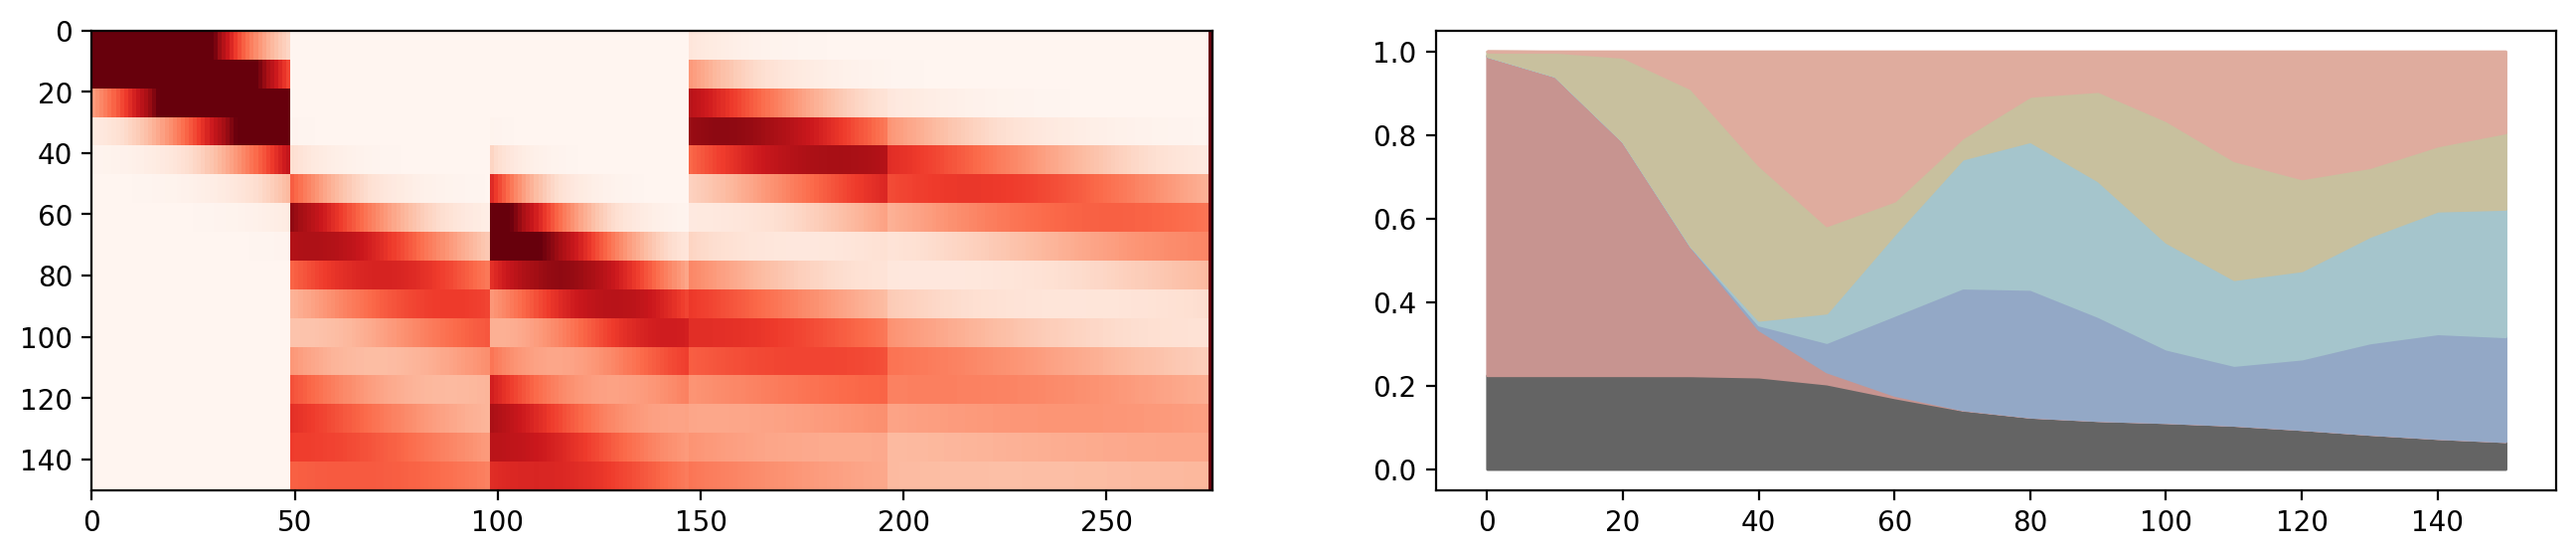

In [57]:
model.plot_H()